# The months view: is Retail-Plus the tier that is slipping?

**Week 2, Thursday. Round 3 of 3.** The question: what did each Retail-Plus member spend in
each month from April to September, and how far did the tier fall from Q1 to Q2?

> **The client's ask.** The head of Retail-Plus: "Give me one row per member and one column
> per month. I want to read along a row and see who is drifting, and I want the tier's fall
> from Q1 to Q2 in one number I can take to the review."

> **Kavya's review.** "A reshape changes the question a table answers, and a pivot also
> aggregates, whether you asked it to or not. Show me the grand total of your pivot next to
> the total of the orders it came from."

Round 1 built the table, round 2 attached the sale. This round changes its shape: months as
columns to compare, months as rows to follow a trend.

**Setup.** The warehouse tables, a month label on every order, and the Retail-Plus orders.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

orders = orders.assign(month=orders["order_date"].dt.to_period("M").astype(str))
plus = orders.merge(customers, on="customer_id", validate="many_to_one").query("segment == 'Retail-Plus'")
MONTHS = sorted(orders["month"].unique())
print(f"{len(plus)} Retail-Plus orders from {plus['customer_id'].nunique()} members, months {MONTHS[0]} to {MONTHS[-1]}")

1,000 orders and 340 customers read from the warehouse
355 Retail-Plus orders from 107 members, months 2026-04 to 2026-09


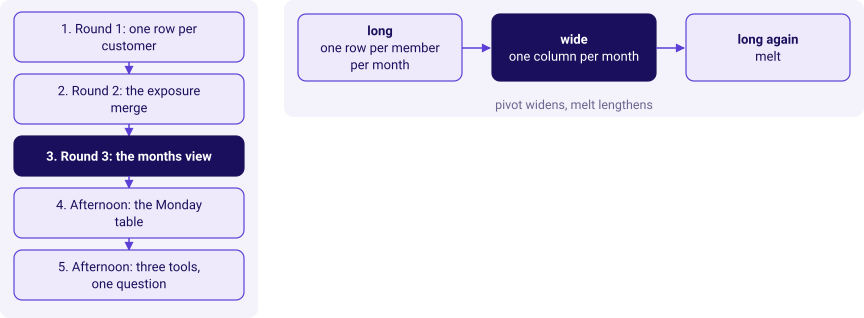

In [2]:
kit.side_by_side(
    kit.ladder(['Round 1: one row per customer', 'Round 2: the exposure merge', 'Round 3: the months view', 'Afternoon: the Monday table', 'Afternoon: three tools, one question'], lit=2, show=False),
    kit.flow(["long\none row per member per month", "wide\none column per month",
              "long again\nmelt"], lit=1, title="pivot widens, melt lengthens", show=False),
)

## 1. The long table: one row per member per month

Before any pivot, the grain the head of Retail-Plus asked about is member and month. Two
keys in the `groupby` give one row per pair that actually has orders.

**Predict before you run.** How many rows does the long table have?
a) 355, one per order; b) 642, members times months; c) 266; d) 107.

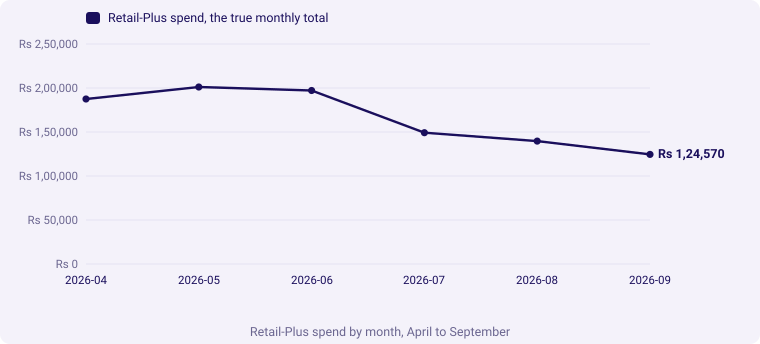

In [3]:
long = plus.groupby(["customer_id", "month"], as_index=False)["amount"].sum()
tier = long.groupby("month")["amount"].sum()
kit.line(MONTHS, [("Retail-Plus spend, the true monthly total", tier.tolist(), "lit")], fmt=kit.rupees,
         title="Retail-Plus spend by month, April to September")
kit.check("the long table keeps every rupee", long["amount"].sum() == plus["amount"].sum(),
          kit.rupees(long["amount"].sum()))
kit.check("one row per member-month that has orders", len(long) == 266, f"{len(long)} rows")

customer_id,month,amount
C-0151,2026-04,"Rs 2,640"
C-0151,2026-06,"Rs 6,290"
C-0151,2026-07,"Rs 2,250"
C-0151,2026-08,"Rs 8,660"
C-0152,2026-05,"Rs 3,170"
C-0152,2026-06,"Rs 10,230"


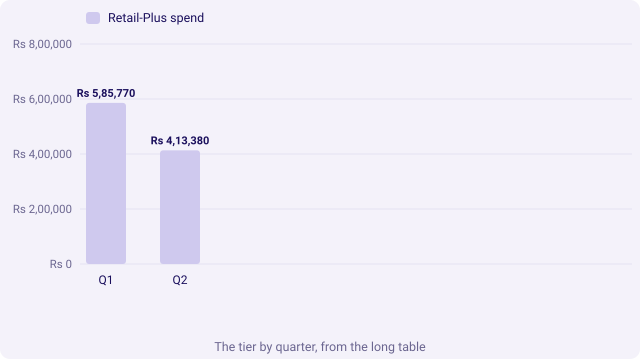

In [4]:
kit.table(["customer_id", "month", "amount"],
          [(r.customer_id, r.month, kit.rupees(r.amount)) for r in long.head(6).itertuples()],
          caption="The long table's first rows: one member, one month, one total")
kit.columns(["Q1", "Q2"], [("Retail-Plus spend", [int(tier[MONTHS[:3]].sum()), int(tier[MONTHS[3:]].sum())])],
            fmt=kit.rupees, width=640, title="The tier by quarter, from the long table")

**What happened.** The answer is c: 266. A member-month with no orders has no row at all, so
the long table is shorter than 107 members times 6 months. The line is the number to hold
on to: the tier took Rs 5,85,770 in Q1 and Rs 4,13,380 in Q2.

## 2. The trap: pivot_table averages unless you tell it to add

**The plausible wrong answer.** The analyst asks for months as columns in one line and sums
each column for the tier's monthly spend.

**Predict before you run.** What fall from Q1 to Q2 does that pivot report?
a) 29 percent; b) 18 percent; c) 0 percent; d) it raises an error.

In [5]:
wide_wrong = plus.pivot_table(index="customer_id", columns="month", values="amount")
col_wrong = wide_wrong.sum()
q1_w, q2_w = col_wrong[MONTHS[:3]].sum(), col_wrong[MONTHS[3:]].sum()
kit.stats([(kit.rupees(round(q1_w)), "Q1, from the pivot", "April to June"),
           (kit.rupees(round(q2_w)), "Q2, from the pivot", "July to September"),
           (f"{q2_w / q1_w - 1:.0%}", "the fall it reports", "what the review would hear")])

**What happened.** The answer is b: a fall of 18 percent. **Why it is wrong.**
`pivot_table`'s default `aggfunc` is `"mean"`, so a member who ordered four times in June
shows the average of the four orders, and the column sums add up averages. The average
order hides how often members bought, and frequency is the lever Week 1 found moving in
Retail-Plus. The true fall is 29 percent, so the head of Retail-Plus would walk into the
review defending a problem two-thirds of its real size.

**The check that catches it.** A pivot of spend must hold the same total as the orders it
came from. Here the grand total is short by a quarter.

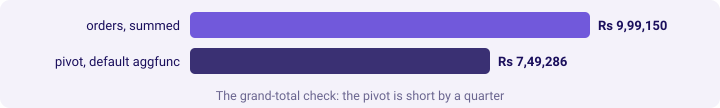

In [6]:
grand_wrong = wide_wrong.sum().sum()
kit.check("the averaged pivot does not add back to the orders", round(grand_wrong) != plus["amount"].sum(),
          f"{kit.rupees(round(grand_wrong))} against {kit.rupees(plus['amount'].sum())}")
kit.bars([("orders, summed", int(plus["amount"].sum())), ("pivot, default aggfunc", round(grand_wrong))],
         fmt=kit.rupees, lit=(1,), title="The grand-total check: the pivot is short by a quarter")

In [7]:
member = "C-0152"
kit.table(["month", "orders", "the pivot shows", "the member spent"],
          [(m, int((plus["customer_id"].eq(member) & plus["month"].eq(m)).sum()),
            "" if pd.isna(wide_wrong.loc[member, m]) else kit.rupees(wide_wrong.loc[member, m]),
            kit.rupees(plus.loc[plus["customer_id"].eq(member) & plus["month"].eq(m), "amount"].sum()))
           for m in MONTHS], caption=f"One member, {member}, read along the row")
kit.check("in June the pivot shows this member's average order, a quarter of the month's spend",
          wide_wrong.loc[member, "2026-06"] * 4 == plus.loc[plus["customer_id"].eq(member)
                                                            & plus["month"].eq("2026-06"), "amount"].sum())

month,orders,the pivot shows,the member spent
2026-04,0,,Rs 0
2026-05,1,"Rs 3,170","Rs 3,170"
2026-06,4,"Rs 2,557","Rs 10,230"
2026-07,2,"Rs 2,780","Rs 5,560"
2026-08,0,,Rs 0
2026-09,2,"Rs 3,440","Rs 6,880"


**The fix.** Say what the cell means: `aggfunc="sum"` adds a member's orders in the month,
and `fill_value=0` writes a month with no orders as 0 spend rather than a gap.

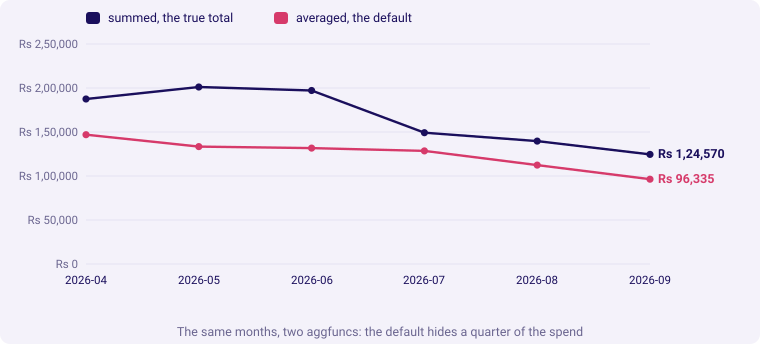

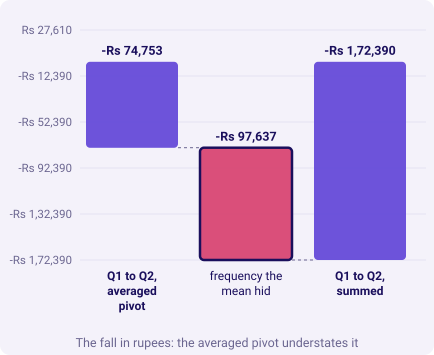

In [8]:
wide = plus.pivot_table(index="customer_id", columns="month", values="amount", aggfunc="sum", fill_value=0)
col = wide.sum()
q1, q2 = col[MONTHS[:3]].sum(), col[MONTHS[3:]].sum()
kit.line(MONTHS, [("summed, the true total", col.tolist(), "lit"),
                  ("averaged, the default", col_wrong.round(0).tolist(), "bad")], fmt=kit.rupees,
         title="The same months, two aggfuncs: the default hides a quarter of the spend")
kit.bridge(("Q1 to Q2, averaged pivot", round(q2_w - q1_w)), [("frequency the mean hid", round((q2 - q1) - (q2_w - q1_w)))],
           end_label="Q1 to Q2, summed", title="The fall in rupees: the averaged pivot understates it",
           lit=(0,))
kit.check("the summed pivot adds back to every Retail-Plus order", wide.values.sum() == plus["amount"].sum(),
          kit.rupees(wide.values.sum()))
kit.check("the true fall from Q1 to Q2 is 29 percent", round(q2 / q1 - 1, 3) == -0.294, f"{q2 / q1 - 1:.1%}")

**Your turn.** The head of Retail-Core asks for the same view of her members. In the empty
cell, build it with `aggfunc="sum"` and `fill_value=0`, then check its grand total against
the Retail-Core orders before you read a single month. Say the Q1 to Q2 change aloud.

## 3. A pivot on the wrong index answers a question nobody asked

The index decides what one row is. Index by `order_id` and every order becomes a row,
which is a table of orders with five empty cells in each, and it looks like a months view
until somebody reads the row labels aloud.

**Predict before you run.** What shape is the pivot indexed by `order_id`?
a) 107 rows by 6 columns; b) 355 rows by 6 columns; c) 6 rows by 107 columns;
d) 120 rows by 6 columns.

index,shape,first row label,one row is
customer_id,"(107, 6)",C-0151,a member
order_id,"(355, 6)",KR-00125,an order


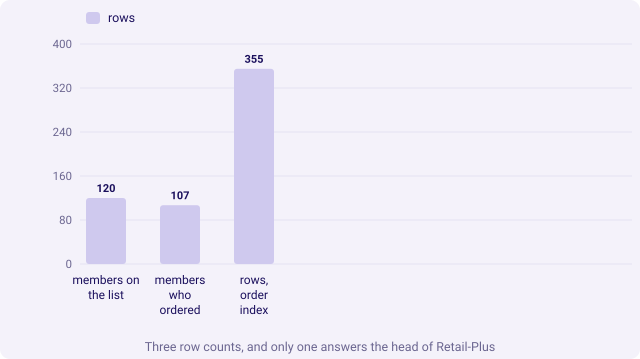

In [9]:
by_order = plus.pivot_table(index="order_id", columns="month", values="amount", aggfunc="sum")
kit.table(["index", "shape", "first row label", "one row is"],
          [("customer_id", str(wide.shape), wide.index[0], "a member"),
           ("order_id", str(by_order.shape), by_order.index[0], "an order")],
          caption="Read the row labels aloud before reading any number")
kit.columns(["members on the list", "members who ordered", "rows, order index"],
            [("rows", [int((customers["segment"] == "Retail-Plus").sum()), len(wide), len(by_order)])],
            width=640, title="Three row counts, and only one answers the head of Retail-Plus")
kit.check("the member view has one row per member who ordered", len(wide) == plus["customer_id"].nunique())
kit.check("the order-indexed pivot has one row per order", len(by_order) == len(plus))

**What happened.** The answer is b: 355 rows, one per Retail-Plus order. Its totals are
right, which is why it survives a glance; its rows are orders, so "who is drifting" cannot
be read from it at all. The member view has 107 rows, and the 13 members on the list who
never ordered are absent from both, which is a decision to state when the view goes out.

## 4. Two shapes, two questions: compare wide, follow long

Months as columns answer a comparison: did this member spend less in Q2 than in Q1? Months
as rows answer a trend, and `melt` turns the wide table back into long.

customer_id,Q1,Q2,change
C-0183,"Rs 16,310","Rs 7,140","-Rs 9,170"
C-0173,"Rs 16,170","Rs 4,320","-Rs 11,850"
C-0177,"Rs 15,160","Rs 4,350","-Rs 10,810"
C-0219,"Rs 14,250","Rs 6,390","-Rs 7,860"
C-0185,"Rs 13,560","Rs 3,350","-Rs 10,210"


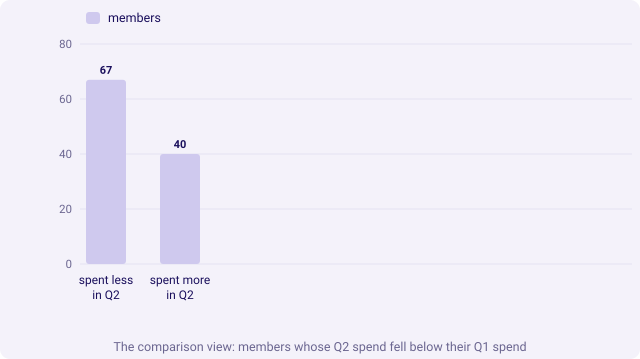

In [10]:
q = wide.assign(Q1=wide[MONTHS[:3]].sum(axis=1), Q2=wide[MONTHS[3:]].sum(axis=1))
kit.table(["customer_id", "Q1", "Q2", "change"],
          [(cid, kit.rupees(r.Q1), kit.rupees(r.Q2), kit.rupees(r.Q2 - r.Q1))
           for cid, r in q.sort_values("Q1", ascending=False).head(5).iterrows()],
          caption="The comparison view: the five biggest Q1 members, Q1 against Q2")
fell = int((q["Q2"] < q["Q1"]).sum())
kit.columns(["spent less in Q2", "spent more in Q2"], [("members", [fell, int((q["Q2"] > q["Q1"]).sum())])],
            width=640, title="The comparison view: members whose Q2 spend fell below their Q1 spend")
back = wide.reset_index().melt(id_vars="customer_id", var_name="month", value_name="spend")
kit.check("melt gives 107 members times 6 months", len(back) == 107 * 6, f"{len(back)} rows")
kit.check("melt keeps every rupee", back["spend"].sum() == plus["amount"].sum())

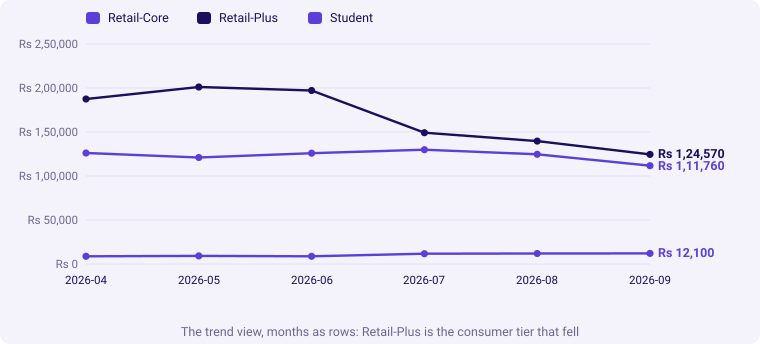

In [11]:
seg = (orders.merge(customers, on="customer_id", validate="many_to_one")
             .pivot_table(index="month", columns="segment", values="amount", aggfunc="sum"))
kit.line(MONTHS, [(s, seg[s].tolist(), "lit" if s == "Retail-Plus" else "") for s in
                  ["Retail-Core", "Retail-Plus", "Student"]], fmt=kit.rupees,
         title="The trend view, months as rows: Retail-Plus is the consumer tier that fell")
kit.check("the segment view adds to the book, Rs 19,84,00,000", seg.values.sum() == 198_400_000)

> **Kavya's review.** "Q1 Rs 5,85,770, Q2 Rs 4,13,380, a fall of 29 percent, from a pivot
> whose grand total equals the orders. The averaged version would have told the review 18.
> Write `aggfunc=` every time, the way you write `how=` on a merge."

### In the interview

**[F] pivot against melt: which widens and which lengthens?** "`pivot` and `pivot_table`
widen: the values of one column become new columns, so a long table of member and month
becomes one row per member with a column per month. `melt` lengthens: it folds columns back
into rows, giving one row per member per month. I pivot to compare across a row and melt to
plot or group a trend."

**Follow-up: your pivot's totals look low. Where do you look first?** "At `aggfunc`.
`pivot_table` averages by default, so if the cells should be totals I pass `aggfunc='sum'`
and check the grand total against the source."

**Follow-up: pivot or pivot_table?** "`pivot` only reshapes, so it raises when a row and
column pair repeats; `pivot_table` aggregates repeats, silently, with the mean unless told
otherwise. When I expect one value per cell, `pivot` is the loud check."

### Depth: `pivot` is the loud version of `pivot_table`

In [12]:
with kit.expect_error() as loud:
    plus.pivot(index="customer_id", columns="month", values="amount")
kit.check("pivot refuses to reshape when a member has two orders in a month",
          loud.name == "ValueError" and "duplicate entries" in loud.message, loud.message)

What this round established,The evidence
the long table is the member-month grain,"266 rows, every rupee kept"
pivot_table averages by default,the tier's fall read 18 percent; it is 29
a pivot's grand total must equal its source,"Rs 7,49,286 against Rs 9,99,150"
the index decides what one row is,355 order rows against 107 members
"wide compares, long follows a trend",67 members spent less in Q2; melt gives 642 rows


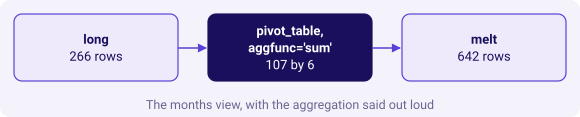

Next: the afternoon builds the whole Monday table unguided, then asks the question a third way.


In [13]:
kit.table(["What this round established", "The evidence"],
          [("the long table is the member-month grain", "266 rows, every rupee kept"),
           ("pivot_table averages by default", "the tier's fall read 18 percent; it is 29"),
           ("a pivot's grand total must equal its source", "Rs 7,49,286 against Rs 9,99,150"),
           ("the index decides what one row is", "355 order rows against 107 members"),
           ("wide compares, long follows a trend", "67 members spent less in Q2; melt gives 642 rows")],
          caption="Round 3")
kit.flow(["long\n266 rows", "pivot_table, aggfunc='sum'\n107 by 6", "melt\n642 rows"], lit=1,
         title="The months view, with the aggregation said out loud")
kit.check_summary()
print("Next: the afternoon builds the whole Monday table unguided, then asks the question a third way.")